In [ ]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [116]:
# Global variables
df_meta = pd.read_csv("SAMPLE_INFO.txt", sep="\t")
tpm_rady_file = "TPM_rady_074"
df_SJ_background_filtered = pd.read_csv("TPM_SJ_background_filtered.csv")
tpm_rady = pd.read_csv("TPM_combined_rady_files.tsv", sep="\t")[["symbol", tpm_rady_file]].set_index("symbol")
max_cols = 4
cancer_types = ["BT", "HGG", "LGG", "MB"]
relevant_genes = ["TP53", "IDH1", "ATRX", "EGFR", "PTEN", "TERT", "NF1", "PIK3CA", "FUBP1", "PIK3R1", "BRAF", "RB1", "BRCA2", "MYC", "SMARCB1", "KIAA1549", "FGFR1", "CDKN2A", "CDKN2B", "PDGFRA", "MYCN", "ACVR1", "CTNNB1", "DDX3X", "PTCH1", "SUFU"]
hla_genes = ["HLA-A", "HLA-B", "HLA-C", "HLA-DPA1", "HLA-DPB1", "HLA-DRB1", "HLA-DQA1", "HLA-DQB1"]
antigen_genes = ["B2M", "CALR", "CANX", "ERAP1", "HSPA5", "IFI30", "NLRC5", "P4HB", "PDIA3", "PSMB10", "PSMB9", "PSME1", "PSME2", "TAP1", "TAP2", "TAPBP", "TAPBPL", "UGT1A1", "CD274", "CTLA4", "LAG3", "PDCD1", "TNFRSF4", "CXCL13"]

/carter/users/affav3/jupyter-env/lib64/python3.6/site-packages/IPython/core/interactiveshell.py:3072: DtypeWarning: Columns (9,10) have mixed types.Specify dtype option on import or set low_memory=False.
  interactivity=interactivity, compiler=compiler, result=result)


In [117]:
# Filter out SJ samples that are in BT, HGG, LGG, or MB
df_meta_sj = df_meta[df_meta["sample_name"].str.startswith("SJ")]
df_meta_sj = df_meta_sj[df_meta_sj["sj_diseases"].isin(cancer_types)]
valid_sj  = df_meta_sj["subject_name"].tolist()
valid_sj = list(set(valid_sj))
print("Valid SJ: ", valid_sj[:10])
print()
# Create a clean ID mapping -> cancer type
sj_to_cancer = df_meta_sj.set_index("subject_name")["sj_diseases"].to_dict()
print("(SJ -> Cancer Type): ", list(sj_to_cancer.items())[:10])

Valid SJ:  ['SJ009023', 'SJ009066', 'SJ031166', 'SJ030728', 'SJ030779', 'SJ009037', 'SJ031165', 'SJ030670', 'SJ030154', 'SJ030305']

(SJ -> Cancer Type):  [('SJ031135', 'BT'), ('SJ031136', 'BT'), ('SJ030775', 'HGG'), ('SJ031097', 'HGG'), ('SJ031139', 'HGG'), ('SJ031140', 'HGG'), ('SJ031096', 'LGG'), ('SJ031127', 'LGG'), ('SJ031112', 'MB'), ('SJ031126', 'MB')]


In [118]:
columns = df_SJ_background_filtered.columns
for cancer in cancer_types:
    sj_ids = [sj for sj in columns if sj_to_cancer.get(sj) == cancer]
    print(f"{cancer}: {len(sj_ids)} samples")

BT: 77 samples
HGG: 111 samples
LGG: 125 samples
MB: 98 samples


In [119]:
# Filter by relevant genes
df_relevant_genes = df_SJ_background_filtered[df_SJ_background_filtered["Gene"].isin(relevant_genes)]
df_relevant_genes.set_index("Gene", inplace=True)

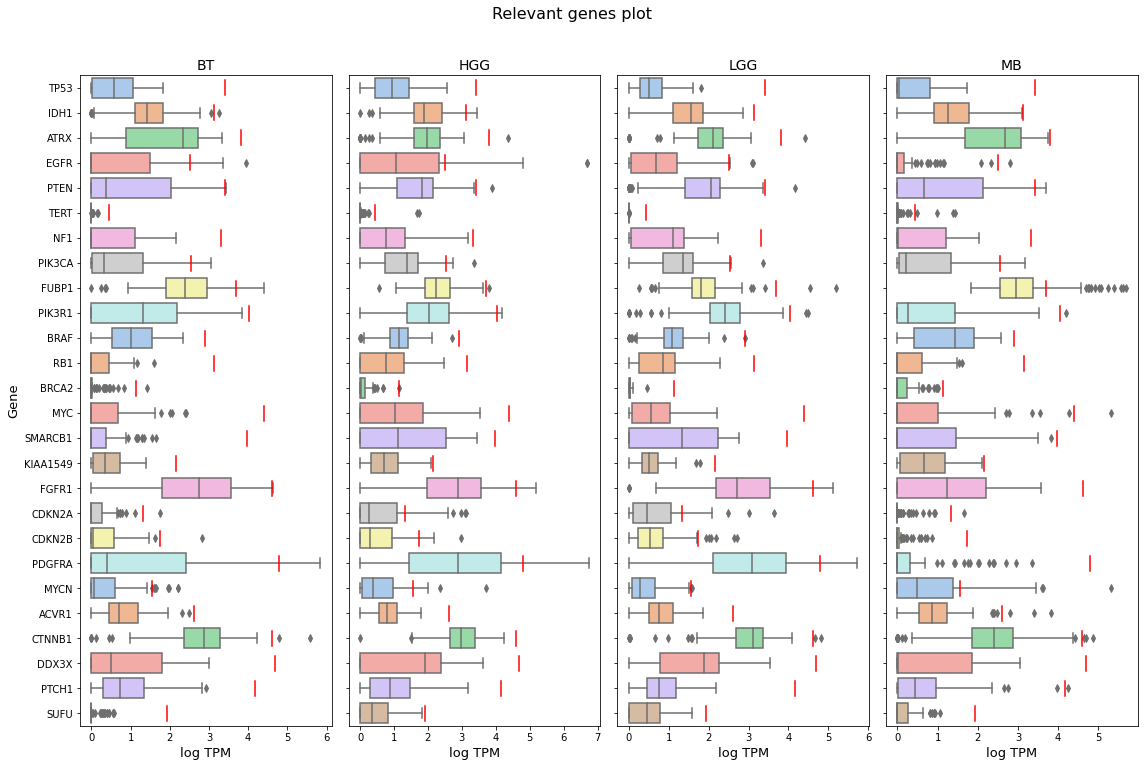

In [120]:
n_cancers = len(cancer_types)
n_blocks = math.ceil(n_cancers / max_cols)
n_genes = len(relevant_genes)

fig, axes = plt.subplots(
    nrows=n_blocks,
    ncols=max_cols,
    figsize=(4 * max_cols, 0.4 * len(relevant_genes)),
    sharey='row'
)
axes = axes.reshape(n_blocks, max_cols)

palette_cancer = sns.color_palette("pastel", n_colors=len(relevant_genes))
gene_colors = dict(zip(relevant_genes, palette_cancer))

for idx, cancer in enumerate(cancer_types):
    block = idx // max_cols
    col = idx % max_cols
    ax = axes[block, col]

    data_long = [
        {"Gene": gene, "TPM": np.log(v + 1)}
        for gene in relevant_genes
        for v in df_relevant_genes.loc[gene, [sj for sj in df_relevant_genes.columns
                                             if sj_to_cancer.get(sj) == cancer]].values
    ]
    
    df_plot = pd.DataFrame(data_long)

    sns.boxplot(x="TPM", y="Gene", data=df_plot, order=relevant_genes,
                palette=gene_colors, ax=ax)
    
    for i, gene in enumerate(relevant_genes):
        tpm_val = tpm_rady[tpm_rady_file].get(gene, None)
        if tpm_val is not None:
            tpm_log = np.log(tpm_val + 1)
            y_pos = i
            ax.plot([tpm_log, tpm_log], [y_pos - 0.3, y_pos + 0.3], color="red", linewidth=1.5)

    ax.set_title(cancer, fontsize=14)
    ax.set_xlabel("log TPM", fontsize=13)
    ax.set_ylabel("" if col else "Gene", fontsize=13)

for idx in range(n_genes, n_blocks * max_cols):
    fig.delaxes(axes.ravel()[idx])

plt.suptitle("Relevant genes plot", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [121]:
# Filter by HLA
df_hla_genes = df_SJ_background_filtered[df_SJ_background_filtered["Gene"].isin(hla_genes)]
df_hla_genes.set_index("Gene", inplace=True)

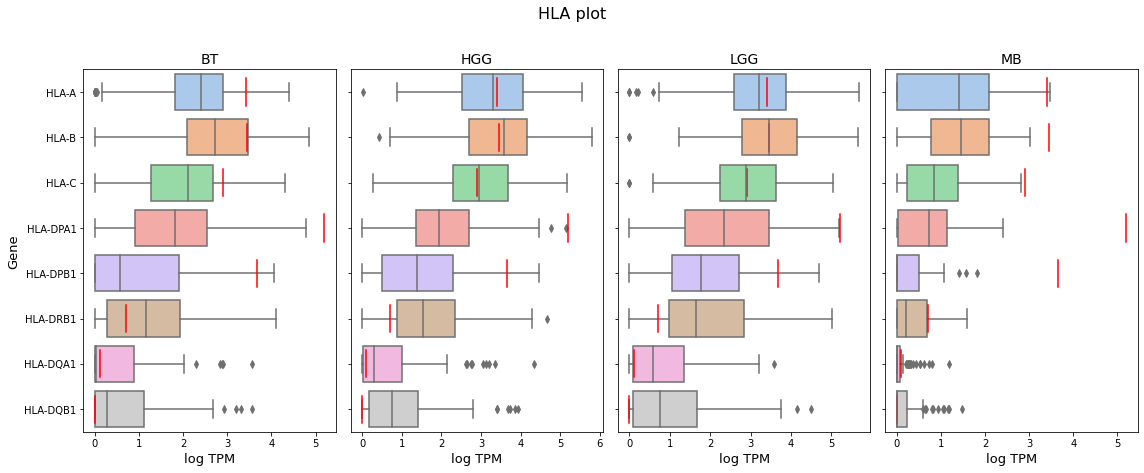

In [122]:
n_cancers = len(cancer_types)
n_blocks = math.ceil(n_cancers / max_cols)
n_genes = len(hla_genes)

fig, axes = plt.subplots(
    nrows=n_blocks,
    ncols=max_cols,
    figsize=(4 * max_cols, 0.8 * len(hla_genes)),
    sharey='row'
)
axes = axes.reshape(n_blocks, max_cols)

palette_cancer = sns.color_palette("pastel", n_colors=len(hla_genes))
gene_colors = dict(zip(hla_genes, palette_cancer))

for idx, cancer in enumerate(cancer_types):
    block = idx // max_cols
    col = idx % max_cols
    ax = axes[block, col]

    data_long = [
        {"Gene": gene, "TPM": np.log(v + 1)}
        for gene in hla_genes
        for v in df_hla_genes.loc[gene, [sj for sj in df_hla_genes.columns
                                             if sj_to_cancer.get(sj) == cancer]].values
    ]
    
    df_plot = pd.DataFrame(data_long)

    sns.boxplot(x="TPM", y="Gene", data=df_plot, order=hla_genes,
                palette=gene_colors, ax=ax)
    
    for i, gene in enumerate(hla_genes):
        tpm_val = tpm_rady[tpm_rady_file].get(gene, None)
        if tpm_val is not None:
            tpm_log = np.log(tpm_val + 1)
            y_pos = i
            ax.plot([tpm_log, tpm_log], [y_pos - 0.3, y_pos + 0.3], color="red", linewidth=1.5)

    ax.set_title(cancer, fontsize=14)
    ax.set_xlabel("log TPM", fontsize=13)
    ax.set_ylabel("" if col else "Gene", fontsize=13)

for idx in range(n_genes, n_blocks * max_cols):
    fig.delaxes(axes.ravel()[idx])

plt.suptitle("HLA plot", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [123]:
# Filter by Antigen
df_antigen_genes = df_SJ_background_filtered[df_SJ_background_filtered["Gene"].isin(antigen_genes)]
df_antigen_genes.set_index("Gene", inplace=True)

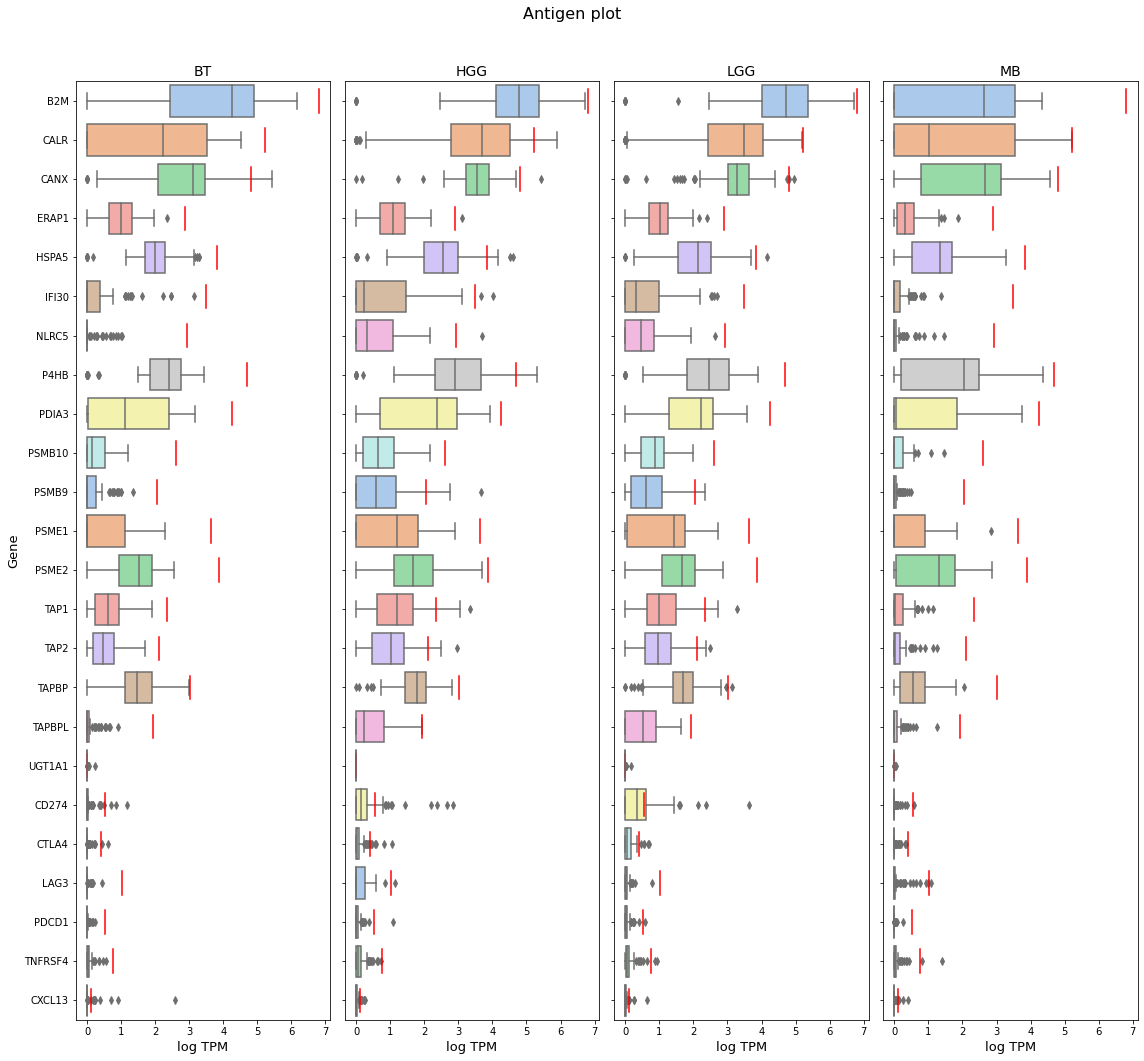

In [124]:
n_cancers = len(cancer_types)
n_blocks = math.ceil(n_cancers / max_cols)

fig, axes = plt.subplots(
    nrows=n_blocks,
    ncols=max_cols,
    figsize=(4 * max_cols, 0.6 * len(antigen_genes)),
    sharey='row'
)
axes = axes.reshape(n_blocks, max_cols)

palette_cancer = sns.color_palette("pastel", n_colors=len(antigen_genes))
gene_colors = dict(zip(antigen_genes, palette_cancer))

for idx, cancer in enumerate(cancer_types):
    block = idx // max_cols
    col = idx % max_cols
    ax = axes[block, col]

    data_long = [
        {"Gene": gene, "TPM": np.log(v + 1)}
        for gene in antigen_genes
        for v in df_antigen_genes.loc[gene, [sj for sj in df_antigen_genes.columns
                                             if sj_to_cancer.get(sj) == cancer]].values
    ]
    
    df_plot = pd.DataFrame(data_long)

    sns.boxplot(x="TPM", y="Gene", data=df_plot, order=antigen_genes,
                palette=gene_colors, ax=ax)
    
    for i, gene in enumerate(antigen_genes):
        tpm_val = tpm_rady[tpm_rady_file].get(gene, None)
        if tpm_val is not None:
            tpm_log = np.log(tpm_val + 1)
            y_pos = i
            ax.plot([tpm_log, tpm_log], [y_pos - 0.3, y_pos + 0.3], color="red", linewidth=1.5)

    ax.set_title(cancer, fontsize=14)
    ax.set_xlabel("log TPM", fontsize=13)
    ax.set_ylabel("" if col else "Gene", fontsize=13)

for idx in range(n_genes, n_blocks * max_cols):
    fig.delaxes(axes.ravel()[idx])

plt.suptitle("Antigen plot", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()